# PROJECT TUGAS: Pengenalan Wajah (Eigenface) Menggunakan SVD dengan Folder 'faces'

Notebook ini menggunakan data citra riil dari folder **`faces`** (berisi Arnold Schwarzenegger, Sylvester Stallone, dan Elizabeth Taylor). 

Program dirancang cerdas agar **mendukung dual-mode** (dapat berjalan lokal di VS Code Anda maupun di Google Colab cloud)!

## 1. Import Library & Setup Deteksi Lingkungan (Colab vs Lokal)

In [1]:
import os
import cv2
import zipfile
import numpy as np
import matplotlib.pyplot as plt

# 1. Mendeteksi Lingkungan Kerja (Google Colab vs PC Lokal)
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

IMG_SIZE = 100

if IN_COLAB:
    print("Mendeteksi Lingkungan: GOOGLE COLAB")
    from google.colab import files
    
    # Jika folder faces belum ada di Colab, minta upload zip
    if not os.path.exists("faces"):
        print("Silakan UPLOAD file zip 'faces.zip' Anda!")
        uploaded = files.upload()
        zip_name = list(uploaded.keys())[0]
        
        # Ekstrak zip ke direktori Colab
        with zipfile.ZipFile(zip_name, 'r') as zip_ref:
            zip_ref.extractall("/content/")
        print("Dataset berhasil diekstrak di Google Colab!")
    dataset_path = "/content/faces"
    
else:
    print("Mendeteksi Lingkungan: LOKAL (VS Code / PC)")
    dataset_path = "faces"
    
    if not os.path.exists(dataset_path):
        raise FileNotFoundError(f"Folder '{dataset_path}' tidak ditemukan! Letakkan folder 'faces' di workspace Anda.")

ModuleNotFoundError: No module named 'cv2'

## 2. Load Dataset Wajah Riil dari Folder 'faces'

Fungsi ini akan meload seluruh citra latih di dalam folder `faces` (mengabaikan file uji berawalan `test`), mengekstrak nama identitas dari nama file (misal: `arnold01.jpg` menjadi `arnold`), me-resize ke $100 \times 100$ grayscale, dan me-flatten menjadi vektor satu dimensi.

In [ ]:
def load_dataset(path):
    data = []
    labels = []
    for file in os.listdir(path):
        # Abaikan file uji yang diawali kata 'test'
        if file.lower().startswith('test'):
            continue
            
        # Ekstrak nama (identitas) dari nama file (misal: 'arnold01.jpg' -> 'arnold')
        name = ''.join([c for c in file.split('.')[0] if not c.isdigit()]).lower()
        
        img_path = os.path.join(path, file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            data.append(img.flatten())
            labels.append(name)
    return np.array(data, dtype=np.float32), np.array(labels)

# Memuat dataset
X, y = load_dataset(dataset_path)

print("===== DETIL DATASET LATIH =====")
print("Jumlah gambar training :", len(X))
print("Ukuran matrix data     :", X.shape)
print("Identitas unik         :", list(np.unique(y)))

===== DETIL DATASET LATIH =====
Jumlah gambar training : 70
Ukuran matrix data     : (70, 10000)
Identitas unik         : [np.str_('arnold'), np.str_('arnold - copy'), np.str_('stallone'), np.str_('taylor')]


## 3. Visualisasi Premium Dataset Pelatihan Wajah

Mari kita tampilkan sampel 5 foto riil untuk masing-masing orang (Arnold, Stallone, Taylor) dari folder `faces/` Anda dalam grid $3 \times 5$ yang sangat rapi.

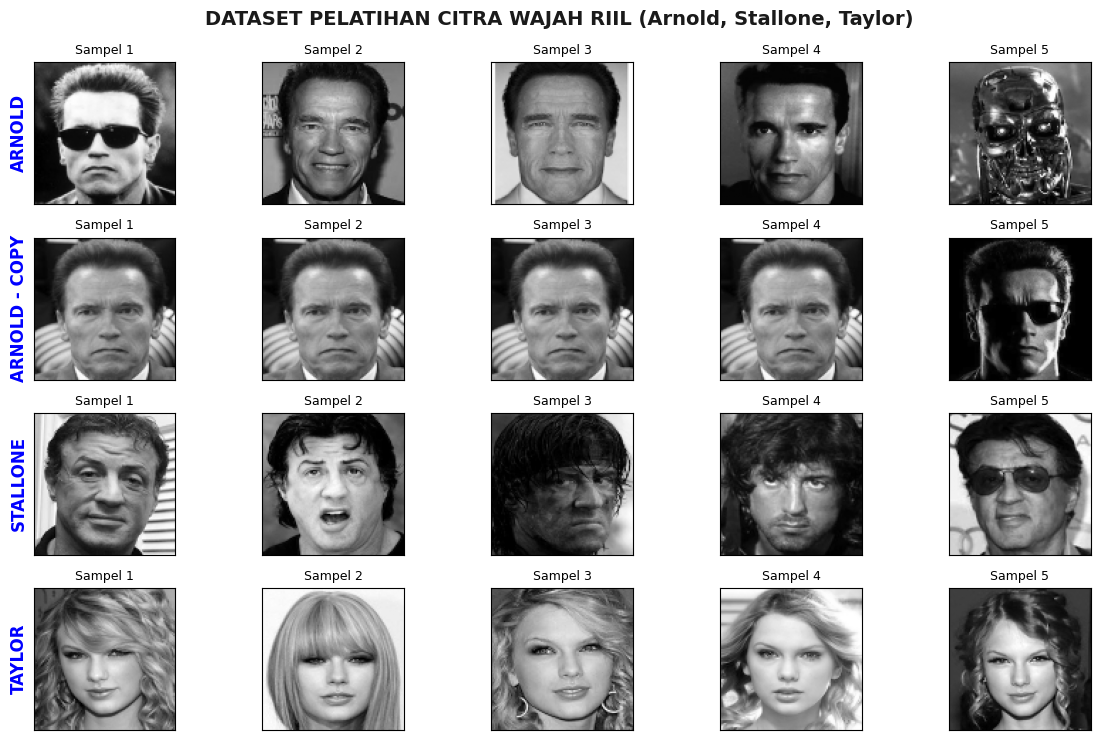

In [ ]:
# Menampilkan sampel 5 gambar untuk masing-masing orang (Total 15 gambar dalam grid 3x5)
unique_names = list(np.unique(y))
num_people = len(unique_names)
num_samples = 5

fig, axes = plt.subplots(num_people, num_samples, figsize=(12, 7.5))
fig.suptitle("DATASET PELATIHAN CITRA WAJAH RIIL (Arnold, Stallone, Taylor)", fontsize=14, fontweight='bold', color='#1a1a1a')

for idx, name in enumerate(unique_names):
    # Dapatkan semua indeks gambar milik orang tersebut
    idxs = np.where(y == name)[0]
    
    # Pilih 5 gambar secara merata dari daftar indeks tersebut
    selected_idxs = [idxs[int(i)] for i in np.linspace(0, len(idxs) - 1, num_samples)]
    
    for sample_idx, img_idx in enumerate(selected_idxs):
        ax = axes[idx, sample_idx]
        face = X[img_idx].reshape(IMG_SIZE, IMG_SIZE)
        ax.imshow(face, cmap='gray')
        
        # Label kolom variasi dan baris nama orang
        if sample_idx == 0:
            ax.set_ylabel(name.upper(), fontsize=12, fontweight='bold', color='blue')
        ax.set_title(f"Sampel {sample_idx+1}", fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

## 4. Normalisasi & Komputasi SVD

In [ ]:
# 1. Hitung Rata-rata Wajah (Mean Face)
mean_face = np.mean(X, axis=0)

# 2. Normalisasi Data (Mean Subtraction)
A = X - mean_face

# 3. Dekomposisi SVD
U, S, VT = np.linalg.svd(A, full_matrices=False)

print("===== HASIL KOMPUTASI DEKOMPOSISI SVD =====")
print("Ukuran U (Bobot Training)  :", U.shape)
print("Ukuran Sigma (Singular)    :", np.diag(S).shape)
print("Ukuran VT (Eigenfaces)     :", VT.shape)

print("\n===== 5 SINGULAR VALUES TERBESAR =====")
for i in range(min(5, len(S))):
    print(f"Singular Value {i+1} = {S[i]:.4f}")

===== HASIL KOMPUTASI DEKOMPOSISI SVD =====
Ukuran U (Bobot Training)  : (70, 70)
Ukuran Sigma (Singular)    : (70, 70)
Ukuran VT (Eigenfaces)     : (70, 10000)

===== 5 SINGULAR VALUES TERBESAR =====
Singular Value 1 = 28454.9492
Singular Value 2 = 18412.0547
Singular Value 3 = 14123.0381
Singular Value 4 = 13157.9961
Singular Value 5 = 10911.9785


## 5. Visualisasi Wajah Eigenface (Ghostly Faces)

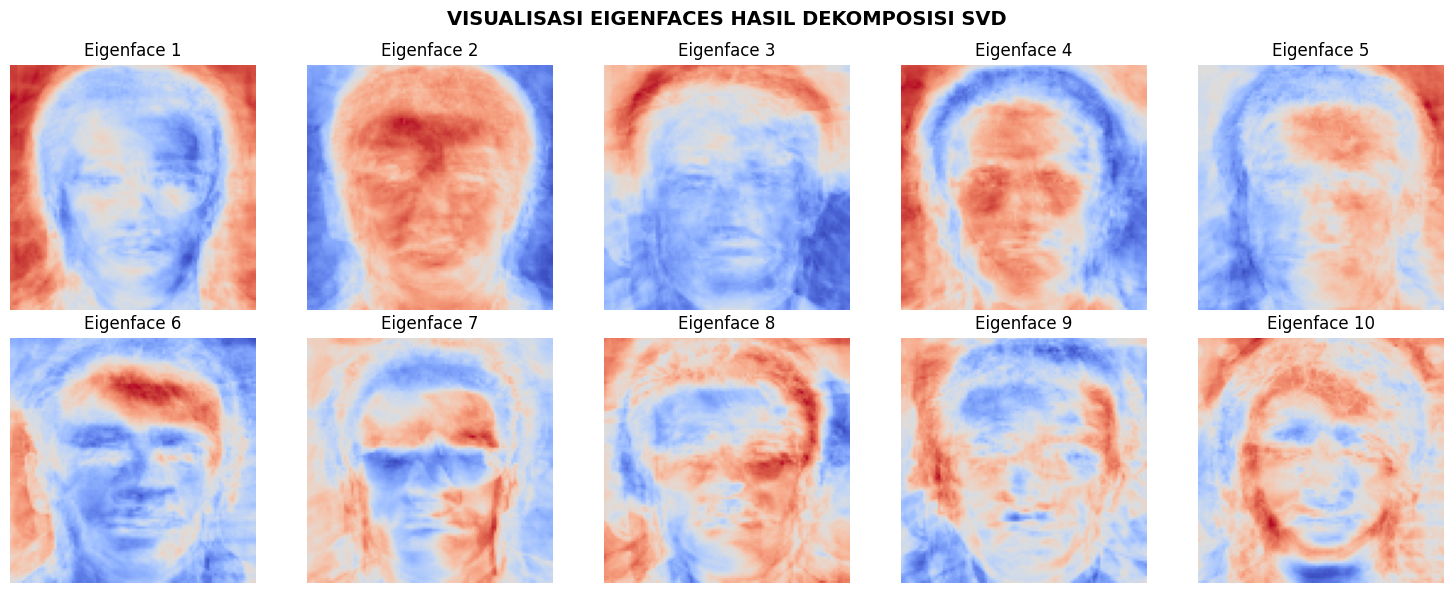

In [ ]:
k = 10
if k > len(VT):
    k = len(VT)

eigenfaces = VT[:k]

plt.figure(figsize=(15, 6))
for i in range(k):
    plt.subplot(2, 5, i+1)
    face = eigenfaces[i].reshape(IMG_SIZE, IMG_SIZE)
    plt.imshow(face, cmap='coolwarm')  # 'coolwarm' untuk visualisasi premium
    plt.title(f"Eigenface {i+1}")
    plt.axis('off')
plt.suptitle("VISUALISASI EIGENFACES HASIL DEKOMPOSISI SVD", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Proyeksi Training Set & Pengujian Wajah Baru

Menggunakan Wajah Uji Lokal: faces\testterminator1.jpg

===== DETIL JARAK EUCLIDEAN TERDEKAT =====
Jarak Terdekat ke ARNOLD = 42.2411
Jarak Terdekat ke ARNOLD - COPY = 6869.3940
Jarak Terdekat ke STALLONE = 4017.2571
Jarak Terdekat ke TAYLOR = 4026.4136

     HASIL PENGENALAN WAJAH SVD
Gambar Uji        : testterminator1.jpg
Prediksi Identitas: ARNOLD
Jarak Terdekat    : 42.24114


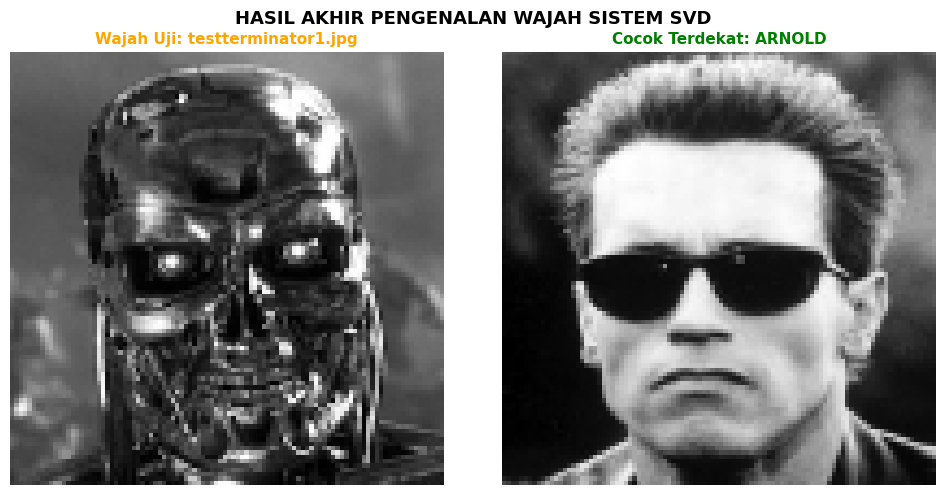

In [ ]:
# 1. Proyeksi training set ke Eigenspace
projected_train = np.dot(A, eigenfaces.T)

# 2. Mengambil gambar uji berdasarkan lingkungan kerja
if IN_COLAB:
    print("\nSilakan UPLOAD gambar wajah uji Anda (misal 'teststallone1.jpg' atau 'testtaylor1.jpg')!")
    from google.colab import files
    uploaded_test = files.upload()
    test_file_path = list(uploaded_test.keys())[0]
else:
    # Mode Lokal: Cari gambar uji berawalan 'test' di folder 'faces'
    # Secara default, mari kita gunakan 'testterminator1.jpg' (uji Arnold)
    test_file_path = os.path.join(dataset_path, "testterminator1.jpg")
    if not os.path.exists(test_file_path):
        test_files = [f for f in os.listdir(dataset_path) if f.lower().startswith('test')]
        if len(test_files) > 0:
            test_file_path = os.path.join(dataset_path, test_files[0])
    print(f"Menggunakan Wajah Uji Lokal: {test_file_path}")

# Load gambar uji
test_img = cv2.imread(test_file_path, cv2.IMREAD_GRAYSCALE)
if test_img is None:
    raise FileNotFoundError(f"Gagal memuat gambar uji dari: {test_file_path}")
test_img = cv2.resize(test_img, (IMG_SIZE, IMG_SIZE))

# 3. Normalisasi & Proyeksi Test Image
test_vector = test_img.flatten().astype(np.float32)
test_normalized = test_vector - mean_face
projected_test = np.dot(test_normalized, eigenfaces.T)

# 4. Hitung Jarak Euclidean ke seluruh training set menggunakan NumPy
distances = np.linalg.norm(projected_train - projected_test, axis=1)

# 5. Klasifikasi: Ambil yang terdekat
best_match_idx = np.argmin(distances)
hasil = y[best_match_idx]

print("\n===== DETIL JARAK EUCLIDEAN TERDEKAT =====")
unique_names = list(np.unique(y))
for name in unique_names:
    idxs = np.where(y == name)[0]
    min_dist_name = np.min(distances[idxs])
    print(f"Jarak Terdekat ke {name.upper()} = {min_dist_name:.4f}")

print("\n====================================")
print("     HASIL PENGENALAN WAJAH SVD")
print("====================================")
print("Gambar Uji        :", os.path.basename(test_file_path))
print("Prediksi Identitas:", hasil.upper())
print("Jarak Terdekat    :", distances[best_match_idx])

# 6. Load Wajah Hasil Match Terdekat untuk Visualisasi
matched_img_idx = np.where(y == hasil)[0][0]
matched_img = X[matched_img_idx].reshape(IMG_SIZE, IMG_SIZE)

# 7. Tampilkan Perbandingan
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(test_img, cmap='gray')
plt.title(f"Wajah Uji: {os.path.basename(test_file_path)}", fontsize=11, fontweight='bold', color='orange')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(matched_img, cmap='gray')
plt.title(f"Cocok Terdekat: {hasil.upper()}", fontsize=11, fontweight='bold', color='green')
plt.axis('off')

plt.suptitle("HASIL AKHIR PENGENALAN WAJAH SISTEM SVD", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()